In [2]:
import numpy as np
import os
import keras
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from keras.models import Sequential
from PIL import Image
from keras.layers import Conv2D,Flatten,Dense,Dropout,BatchNormalization,MaxPooling2D
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
import cv2

In [3]:
path1 = []
path2 = []
path3 = []
path4 = []

In [4]:
# Path to the folder containing images
folder_path = 'C:\\Users\\KIIT\\Downloads\\form\\Myproject\\ML\\archive\\Data\\Non Demented'

# Iterate over each file in the folder
for filename in os.listdir(folder_path):
    # Construct the full file path
    file_path = os.path.join(folder_path, filename)
    path1.append(file_path)


In [5]:
len(path1)

67222

In [6]:
# Path to the folder containing images
folder_path = 'C:/Users/KIIT/Downloads/form/Myproject/ML/archive/Data/Mild Dementia'

# Iterate over each file in the folder
for filename in os.listdir(folder_path):
    # Construct the full file path
    file_path = os.path.join(folder_path, filename)
    path2.append(file_path)

In [7]:
len(path2)

5002

In [8]:
# Path to the folder containing images
folder_path = 'C:/Users/KIIT/Downloads/form/Myproject/ML/archive/Data/Moderate Dementia'

# Iterate over each file in the folder
for filename in os.listdir(folder_path):
    # Construct the full file path
    file_path = os.path.join(folder_path, filename)
    path3.append(file_path)

In [9]:
len(path3)

488

In [10]:
# Path to the folder containing images
folder_path = 'C:/Users/KIIT/Downloads/form/Myproject/ML/archive/Data/Very mild Dementia'

# Iterate over each file in the folder
for filename in os.listdir(folder_path):
    # Construct the full file path
    file_path = os.path.join(folder_path, filename)
    path4.append(file_path)

In [11]:
len(path4)

13725

In [12]:
path1 = path1[0:488]
path2 = path2[0:488]
path3 = path3[0:488]
path4 = path4[0:488]

In [13]:
encoder = OneHotEncoder()
encoder.fit([[0],[1],[2],[3]])

# 0 --> Non Demented
# 1 --> Mild Dementia
# 2 --> Moderate Dementia
# 3 --> Very Mild Dementia

OneHotEncoder()

In [14]:
data = []
result = []
for path in path1:
    img = Image.open(path)
    img1 = img.resize((128,128))
    img2 = np.array(img1)
    if(img2.shape == (128,128,3)):
        data.append(np.array(img2))
        result.append(encoder.transform([[0]]).toarray())

for path in path2:
    img = Image.open(path)
    img1 = img.resize((128,128))
    img2 = np.array(img1)
    if(img2.shape == (128,128,3)):
        data.append(np.array(img2))
        result.append(encoder.transform([[1]]).toarray())

for path in path3:
    img = Image.open(path)
    img = img.resize((128,128))
    img = np.array(img)
    if(img.shape == (128,128,3)):
        data.append(np.array(img))
        result.append(encoder.transform([[2]]).toarray())

for path in path4:
    img = Image.open(path)
    img = img.resize((128,128))
    img = np.array(img)
    if(img.shape == (128,128,3)):
        data.append(np.array(img))
        result.append(encoder.transform([[3]]).toarray())

In [15]:
data = np.array(data)
data.shape

(1952, 128, 128, 3)

In [16]:
result = np.array(result)
result = result.reshape((1952,4))
result.shape

(1952, 4)

In [17]:
x_train,x_test,y_train,y_test = train_test_split(data,result,test_size=0.15,shuffle=True,random_state=42)

In [18]:
from keras.models import Sequential
from keras.optimizers import Adam
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


model = Sequential()

model.add(Conv2D(32,kernel_size =(2,2),input_shape = (128,128,3),padding = 'Same'))
model.add(Conv2D(32,kernel_size =(2,2),activation='relu',padding = 'Same'))

model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(64,kernel_size =(2,2),activation='relu',padding = 'Same'))
model.add(Conv2D(64,kernel_size =(2,2),activation='relu',padding = 'Same'))

model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides = (2,2)))
model.add(Dropout(0.25))

model.add(Flatten())

model.add(Dense(512,activation = 'relu'))
model.add(Dropout(0.5))
model.add(Dense(4,activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

print(model.summary())



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      416       
                                                                 
 conv2d_1 (Conv2D)           (None, 128, 128, 32)      4128      
                                                                 
 batch_normalization (Batch  (None, 128, 128, 32)      128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 64, 64, 32)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 64, 64, 32)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 64, 64, 64)       

In [19]:
y_train.shape

(1659, 4)

In [20]:
x_train.shape

(1659, 128, 128, 3)

In [23]:
model.fit(x_train,y_train,epochs=10,batch_size=10,verbose=1,validation_data=(x_test,y_test))

Epoch 1/10
166/166 [==============================] - 98s 584ms/step - loss: 0.0969 - accuracy: 0.9958 - val_loss: 0.0000e+00 - val_accuracy: 1.0000
Epoch 2/10
166/166 [==============================] - 100s 606ms/step - loss: 0.0715 - accuracy: 0.9958 - val_loss: 5.4112e-08 - val_accuracy: 1.0000
Epoch 3/10
166/166 [==============================] - 104s 629ms/step - loss: 0.0444 - accuracy: 0.9982 - val_loss: 0.0000e+00 - val_accuracy: 1.0000
Epoch 4/10
166/166 [==============================] - 101s 607ms/step - loss: 0.0284 - accuracy: 0.9970 - val_loss: 0.0096 - val_accuracy: 0.9966
Epoch 5/10
166/166 [==============================] - 95s 571ms/step - loss: 0.2981 - accuracy: 0.9934 - val_loss: 0.0000e+00 - val_accuracy: 1.0000
Epoch 6/10
166/166 [==============================] - 95s 571ms/step - loss: 0.4864 - accuracy: 0.9867 - val_loss: 0.2307 - val_accuracy: 0.9932
Epoch 7/10
166/166 [==============================] - 96s 578ms/step - loss: 0.1470 - accuracy: 0.9970 - val_lo

In [27]:
model.save('C:/Users/KIIT/Downloads/form/Myproject/ML/Mymodel1.h5')

C:\Users\KIIT\AppData\Roaming\Python\Python311\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [25]:
plt.plot(model.history['loss'])
plt.plot(model.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Loss')
plt.ylabel('Epoch')
plt.legend(['Test','Validation'],loc='upper right')
plt.show()

TypeError: 'History' object is not subscriptable

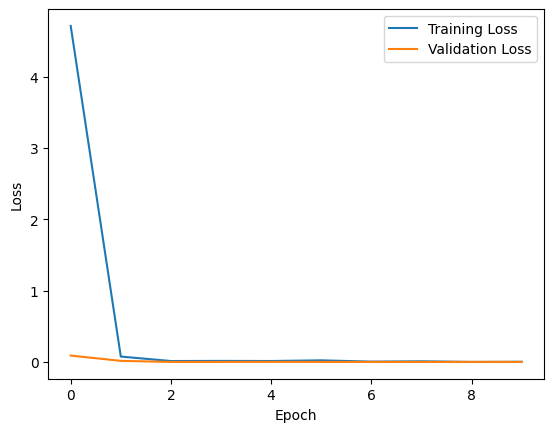

In [ ]:
# Plot training and validation loss curves
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

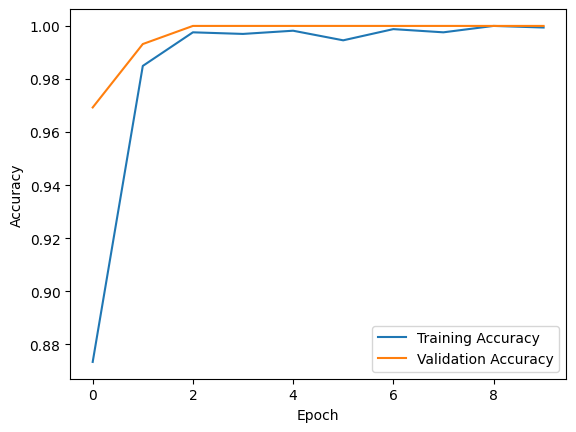

In [ ]:
# Plot training and validation accuracy curves
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
def names(number):
    if number == 0:
        return 'Non Demented'
    elif number == 1:
        return 'Mild Dementia'
    elif number == 2:
        return 'Moderate Dementia'
    elif number == 3:
        return 'Very Mild Dementia'
    else:
        return 'Error in Prediction'
# 0 --> Non Demented
# 1 --> Mild Dementia
# 2 --> Moderate Dementia
# 3 --> Very Mild Dementia

100.0% Confidence This Is Moderate Dementia


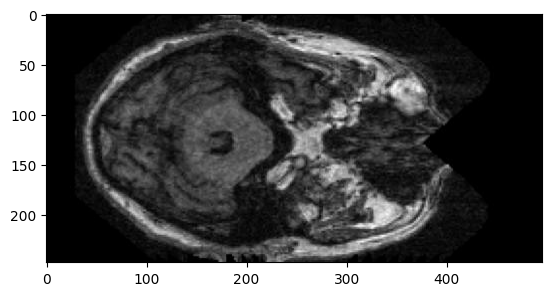

In [ ]:
from matplotlib.pyplot import imshow
img = Image.open(r'C:\Users\KIIT\Downloads\form\Myproject\ML\archive\Data\Moderate Dementia\OAS1_0351_MR1_mpr-4_119.jpg')
x = np.array(img.resize((128,128)))
x = x.reshape(1,128,128,3)
res=model.predict_on_batch(x)
classification = np.where(res == np.amax(res))[1][0]
imshow(img)
print(str(res[0][classification]*100)+ '% Confidence This Is '+ names(classification))

100.0% Confidence This Is Very Mild Dementia


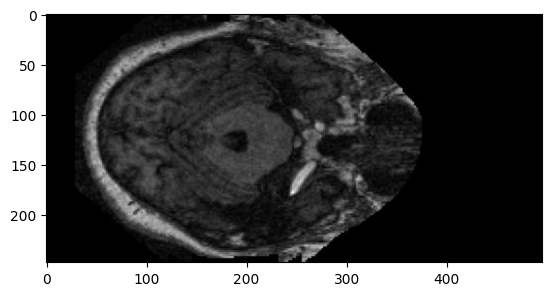

In [ ]:
img = Image.open(r'C:\Users\KIIT\Downloads\form\Myproject\ML\archive\Data\Very mild Dementia\OAS1_0015_MR1_mpr-2_120.jpg')
x = np.array(img.resize((128,128)))
x = x.reshape(1,128,128,3)
res=model.predict_on_batch(x)
classification = np.where(res == np.amax(res))[1][0]
imshow(img)
print(str(res[0][classification]*100)+ '% Confidence This Is '+ names(classification))

100.0% Confidence This Is Very Mild Dementia


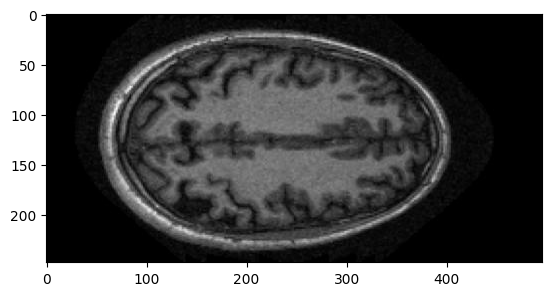

In [ ]:
img = Image.open(r'C:\Users\KIIT\Downloads\form\Myproject\ML\archive\Data\Non Demented\OAS1_0004_MR1_mpr-1_157.jpg')
x = np.array(img.resize((128,128)))
x = x.reshape(1,128,128,3)
res=model.predict_on_batch(x)
classification = np.where(res == np.amax(res))[1][0]
imshow(img)
print(str(res[0][classification]*100)+ '% Confidence This Is '+ names(classification))

In [ ]:
from keras.models import Sequential
from keras.optimizers import Adam
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Define your model
model1 = Sequential()

# Convolutional layers
model1.add(Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same', input_shape=(128, 128, 3)))
model1.add(Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'))
model1.add(MaxPooling2D(pool_size=(2, 2)))
model1.add(Dropout(0.25))

model1.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
model1.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
model1.add(MaxPooling2D(pool_size=(2, 2)))
model1.add(Dropout(0.25))

model1.add(Flatten())

# Dense layers
model1.add(Dense(512, activation='relu'))
model1.add(Dropout(0.5))
model1.add(Dense(4, activation='softmax'))

model1.build(input_shape=(400,128,3,3))
# Compile the model
model1.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
# Print model summary
print(model1.summary())


Model: "sequential_117"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_468 (Conv2D)         (None, 128, 128, 32)      896       
                                                                 
 conv2d_469 (Conv2D)         (None, 128, 128, 32)      9248      
                                                                 
 max_pooling2d_234 (MaxPooli  (None, 64, 64, 32)       0         
 ng2D)                                                           
                                                                 
 dropout_351 (Dropout)       (None, 64, 64, 32)        0         
                                                                 
 conv2d_470 (Conv2D)         (None, 64, 64, 64)        18496     
                                                                 
 conv2d_471 (Conv2D)         (None, 64, 64, 64)        36928     
                                                    

In [ ]:
history1 = model1.fit(x_train,y_train,epochs=10,batch_size=10,verbose=1,validation_data=(x_test,y_test))

Epoch 1/10
166/166 [==============================] - 179s 1s/step - loss: 10.0316 - accuracy: 0.6763 - val_loss: 0.0326 - val_accuracy: 0.9932
Epoch 2/10
166/166 [==============================] - 189s 1s/step - loss: 0.0598 - accuracy: 0.9813 - val_loss: 0.0037 - val_accuracy: 1.0000
Epoch 3/10
166/166 [==============================] - 225s 1s/step - loss: 0.0205 - accuracy: 0.9952 - val_loss: 6.8227e-04 - val_accuracy: 1.0000
Epoch 4/10
166/166 [==============================] - 214s 1s/step - loss: 0.0274 - accuracy: 0.9885 - val_loss: 3.0144e-04 - val_accuracy: 1.0000
Epoch 5/10
166/166 [==============================] - 222s 1s/step - loss: 0.0270 - accuracy: 0.9934 - val_loss: 8.8957e-04 - val_accuracy: 1.0000
Epoch 6/10
166/166 [==============================] - 201s 1s/step - loss: 0.0361 - accuracy: 0.9910 - val_loss: 0.0052 - val_accuracy: 1.0000
Epoch 7/10
166/166 [==============================] - 236s 1s/step - loss: 0.0178 - accuracy: 0.9934 - val_loss: 9.7217e-05 - val

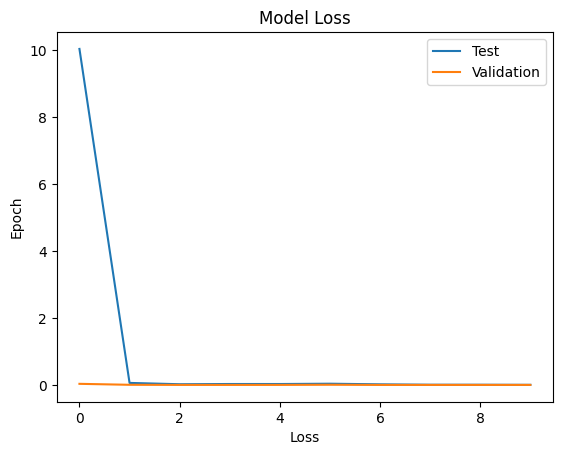

In [ ]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Loss')
plt.ylabel('Epoch')
plt.legend(['Test','Validation'],loc='upper right')
plt.show()

In [ ]:
from keras.wrappers.scikit_learn import KerasClassifier
#from scikeras.wrappers import SciKerasClassifier
from sklearn.model_selection import GridSearchCV
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.optimizers import Adam

# Define your CNN model as a function
def create_model(filters, kernel_size, dropout_rate, learning_rate):

    model = Sequential()

    model.add(Conv2D(filters,kernel_size=kernel_size,input_shape = (128,128,3),padding = 'Same'))
    model.add(Conv2D(filters,kernel_size=kernel_size,activation='relu',padding = 'Same'))

    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(dropout_rate))

    model.add(Conv2D(filters,kernel_size=kernel_size,activation='relu',padding = 'Same'))
    model.add(Conv2D(filters,kernel_size=kernel_size,activation='relu',padding = 'Same'))

    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2),strides = (2,2)))
    model.add(Dropout(dropout_rate))

    model.add(Flatten())

    model.add(Dense(512,activation = 'relu'))
    model.add(Dropout(0.5))
    model.add(Dense(4,activation='softmax'))

    optimizer = Adam(learning_rate=learning_rate)
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

# Create KerasClassifier
model = KerasClassifier(build_fn=create_model, epochs=10, batch_size=32, verbose=0)

# Define the hyperparameters grid
param_grid = {
    'filters': [32, 64],
    'kernel_size': [(2, 2), (4, 4)],
    'dropout_rate': [0.25, 0.5,0.125],
    'learning_rate': [0.001, 0.01,0.05]
}

# Perform GridSearchCV
grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=4)
grid_result = grid.fit(x_train, y_train)  # Provide your training data here

# Summarize results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))


c:\Users\KIIT\anaconda3\envs\harsh\lib\site-packages\ipykernel_launcher.py:38: DeprecationWarning: KerasClassifier is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.


In [28]:
from keras.models import Sequential
from keras.layers import Dense
from keras.wrappers.scikit_learn import KerasClassifier
from sklearn.model_selection import cross_val_score
from sklearn.datasets import make_classification

# Create a function that returns a Keras model
def create_model():
    model = Sequential()
    filters=32
    kernel_size=(2,2)
    dropout_rate=0.25
    learning_rate=0.001
    model.add(Conv2D(filters,kernel_size=kernel_size,input_shape = (128,128,3),padding = 'Same'))
    model.add(Conv2D(filters,kernel_size=kernel_size,activation='relu',padding = 'Same'))

    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(dropout_rate))

    model.add(Conv2D(filters,kernel_size=kernel_size,activation='relu',padding = 'Same'))
    model.add(Conv2D(filters,kernel_size=kernel_size,activation='relu',padding = 'Same'))

    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2),strides = (2,2)))
    model.add(Dropout(dropout_rate))

    model.add(Flatten())

    model.add(Dense(512,activation = 'relu'))
    model.add(Dropout(0.5))
    model.add(Dense(4,activation='softmax'))

    optimizer = Adam(learning_rate=learning_rate)
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model


# Create a SciKerasClassifier
model = KerasClassifier(build_fn=create_model, epochs=10, batch_size=10, verbose=1)

# Generate some example data
X, y = make_classification(n_samples=100, n_features=20, n_classes=2)

# Evaluate the model using cross-validation
scores = cross_val_score(model, x_train, y_train, cv=10)
print("Accuracy: {:.2f} (+/- {:.2f})".format(scores.mean(), scores.std()))


ModuleNotFoundError: No module named 'keras.wrappers'

In [30]:
pip install keras.wrappers

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement keras.wrappers (from versions: none)
ERROR: No matching distribution found for keras.wrappers


In [31]:
img = Image.open(r'C:\Users\KIIT\Downloads\form\Myproject\ML\archive\Data\Moderate Dementia\OAS1_0351_MR1_mpr-4_119.jpg')

In [32]:
type(img)

PIL.JpegImagePlugin.JpegImageFile

In [33]:
x = np.array(img.resize((128,128)))

In [34]:
type(x)

numpy.ndarray

In [36]:
y=x.tolist()

In [40]:
import json
json_data={
    'x' : y
}

In [42]:
json_string = json.dumps(json_data)


In [44]:
print(json_string)

{"x": [[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], [6, 6, 6], [10, 10, 10], [1, 1, 1], [1, 1, 1], [6, 6, 6], [11, 11, 11], [6, 6, 6], [0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], [3, 3, 3], [6, 6, 6], [5, 5, 5], [8, 8, 8], [29, 29, 29], [56, 56, 56], [46, 46, 46], [73, 73, 73], [109, 109, 109], [74, 74, 74], [19, 19, 19], [0, 0, 0], [1, 1, 1], [2, 2, 2], [6, 6, 6], [19, 19, 19], [3, 3, 3], [1, 1, 1], [34, 34, 34], [37, 37, 37], [0, 0, 0], [0, 0, 0], [7, 7, 7], [8, 8, 8], [10, 10, 10], [12, 12, 12], [17, 17, 17], [19, 19, 19], [12, 12, 12], [8, 8, 8], [7, 7, 7], [4, 4, 4], [1, 1, 1], [0, 0, 0], [1, 1, 1], [0, 0, 0], [0, 0, 0], [1, 1, 1], [1, 1, 1], [3, 3, 3], [9, 9, 9], [5, 5, 5], [0, 0, 0], [0, 0, 0], [1, 1, 1], [1,